In [1]:
from sympy import *
from cq.symbolic import *

D = 3
rho = symbol_matrix_symmetric('rho', D+1)
#print(rho._repr_latex_())
rho

Matrix([
[rho00, rho01, rho02, rho03],
[rho01, rho11, rho12, rho13],
[rho02, rho12, rho22, rho23],
[rho03, rho13, rho23, rho33]])

In [2]:
T = T_matrix(D)
T

Matrix([
[       1/4,          0, -sqrt(2)/4,          0],
[         0,        3/4,          0, -sqrt(6)/4],
[-sqrt(2)/4,          0,        5/4,          0],
[         0, -sqrt(6)/4,          0,        7/4]])

In [3]:
T = (rho@T).trace()
#print(T._repr_latex_())
T

rho00/4 - sqrt(2)*rho02/2 + 3*rho11/4 - sqrt(6)*rho13/2 + 5*rho22/4 + 7*rho33/4

In [4]:
g = rho_to_g(rho)
#print(g._repr_latex_())
g

Matrix([
[                                                rho00 + rho11 + rho22 + rho33],
[                                  2*rho01 + 2*sqrt(2)*rho12 + 2*sqrt(3)*rho23],
[2*rho02 + sqrt(2)*rho11 + 2*sqrt(3)*rho13 + 2*sqrt(2)*rho22 + 3*sqrt(2)*rho33],
[                                  2*rho03 + 2*sqrt(3)*rho12 + 6*sqrt(2)*rho23],
[                                    4*rho13 + sqrt(6)*rho22 + 3*sqrt(6)*rho33],
[                                                             2*sqrt(10)*rho23],
[                                                              2*sqrt(5)*rho33]])

## Vector to matrix

In [5]:
equations = g - Matrix(symbols(f'g:{len(g)}'))
equations

Matrix([
[                                                -g0 + rho00 + rho11 + rho22 + rho33],
[                                  -g1 + 2*rho01 + 2*sqrt(2)*rho12 + 2*sqrt(3)*rho23],
[-g2 + 2*rho02 + sqrt(2)*rho11 + 2*sqrt(3)*rho13 + 2*sqrt(2)*rho22 + 3*sqrt(2)*rho33],
[                                  -g3 + 2*rho03 + 2*sqrt(3)*rho12 + 6*sqrt(2)*rho23],
[                                    -g4 + 4*rho13 + sqrt(6)*rho22 + 3*sqrt(6)*rho33],
[                                                             -g5 + 2*sqrt(10)*rho23],
[                                                              -g6 + 2*sqrt(5)*rho33]])

In [6]:
from sympy.abc import x, y, t
from IPython.display import display, Markdown

rho_sol = Matrix(rho)
for i in reversed(range(len(equations))):
    print('Using')
    display(equations[i])
    
    s = sorted(set(rho) & equations[i].free_symbols, key=str)
    print('to solve for')
    display(Matrix(tuple(s)))
    
    p = Poly(equations[i], *s)
    s_sol = linear_solutions(p) if len(s)==1 else linear_solutions(p, Symbol(f't{i}'))
    print('Solution:')
    display(Matrix(s_sol))
    
    subs = dict(zip(s, s_sol))
    
    rho_sol = rho_sol.subs(subs).expand()
    T = T.subs(subs).expand()
    equations = equations.subs(subs).expand()
    print('Resulting in')
    display(rho)
    display(T)
    display(equations)
    display(Markdown('---'))

Using


-g6 + 2*sqrt(5)*rho33

to solve for


Matrix([[rho33]])

Solution:


...

Resulting in


Matrix([
[rho00, rho01, rho02, rho03],
[rho01, rho11, rho12, rho13],
[rho02, rho12, rho22, rho23],
[rho03, rho13, rho23, rho33]])

g0/4 - sqrt(2)*g2/12 + sqrt(5)*g6/5 - 2*t2 - 22*t4/3

Matrix([
[0],
[0],
[0],
[0],
[0],
[0],
[0]])

---

In [7]:
#print(rho_sol._repr_latex_())
rho_sol

Matrix([
[   g0 - sqrt(2)*g2/6 + sqrt(6)*g4/22 - 9*sqrt(5)*g6/110 + 2*t2 + 10*t4/3,             g1/2 - sqrt(6)*g3/8 + sqrt(30)*g5/40 + 2*sqrt(2)*t3, g2/3 - 2*sqrt(3)*g4/11 + 7*sqrt(10)*g6/110 + sqrt(2)*t2 + 2*sqrt(2)*t4/3,   g3/8 - 3*sqrt(5)*g5/40 + 2*sqrt(3)*t3],
[                     g1/2 - sqrt(6)*g3/8 + sqrt(30)*g5/40 + 2*sqrt(2)*t3, sqrt(2)*g2/6 - sqrt(6)*g4/11 + 7*sqrt(5)*g6/110 - 2*t2 + 2*t4/3,                                   sqrt(3)*g3/8 - 3*sqrt(15)*g5/40 - 2*t3, 2*g4/11 - 3*sqrt(30)*g6/55 + sqrt(6)*t4],
[g2/3 - 2*sqrt(3)*g4/11 + 7*sqrt(10)*g6/110 + sqrt(2)*t2 + 2*sqrt(2)*t4/3,                          sqrt(3)*g3/8 - 3*sqrt(15)*g5/40 - 2*t3,                                  sqrt(6)*g4/22 - 9*sqrt(5)*g6/110 - 4*t4,                          sqrt(10)*g5/20],
[                                   g3/8 - 3*sqrt(5)*g5/40 + 2*sqrt(3)*t3,                         2*g4/11 - 3*sqrt(30)*g6/55 + sqrt(6)*t4,                                                           sqrt(10)*g5/20,          

In [8]:
#print(T._repr_latex_())
T

g0/4 - sqrt(2)*g2/12 + sqrt(5)*g6/5 - 2*t2 - 22*t4/3

## Free parameters

In [9]:
t2, t3, t4 = symbols('t2 t3 t4')

In [10]:
from sympy.abc import lamda

P_char = Poly((lamda**(D-1)*(lamda-1)**2).expand(), lamda)
P_char

Poly(lamda**4 - 2*lamda**3 + lamda**2, lamda, domain='ZZ')

In [11]:
P_rho = rho_sol.charpoly(lamda)
P_rho

PurePoly(lamda**4 - g0*lamda**3 + (sqrt(2)*g0*g2/6 - sqrt(6)*g0*g4/22 + 9*sqrt(5)*g0*g6/110 - 2*g0*t2 - 10*g0*t4/3 - g1**2/4 + sqrt(6)*g1*g3/8 - sqrt(30)*g1*g5/40 - 2*sqrt(2)*g1*t3 - g2**2/6 + sqrt(3)*g2*g4/6 - sqrt(10)*g2*g6/15 - 5*g3**2/32 + 9*sqrt(5)*g3*g5/80 + sqrt(3)*g3*t3 - 41*g4**2/242 + 34*sqrt(30)*g4*g6/605 + sqrt(6)*g4*t2/11 - sqrt(6)*g4*t4/33 - 5*g5**2/32 - sqrt(15)*g5*t3/5 - 24*g6**2/121 + 2*sqrt(5)*g6*t2/55 + 64*sqrt(5)*g6*t4/165 - 6*t2**2 - 8*t2*t4 - 24*t3**2 - 62*t4**2/3)*lamda**2 + (-sqrt(3)*g0*g2*g4/66 - sqrt(10)*g0*g2*g6/330 + 2*sqrt(2)*g0*g2*t4/3 + 3*g0*g3**2/64 - 9*sqrt(5)*g0*g3*g5/160 - sqrt(3)*g0*g3*t3/2 + 7*g0*g4**2/121 - 31*sqrt(30)*g0*g4*g6/1210 + sqrt(6)*g0*g4*t2/11 - sqrt(6)*g0*g4*t4/33 + 7*g0*g5**2/64 + 3*sqrt(15)*g0*g5*t3/10 + 301*g0*g6**2/2420 + 2*sqrt(5)*g0*g6*t2/55 - 2*sqrt(5)*g0*g6*t4/165 - 8*g0*t2*t4 + 4*g0*t3**2 + 26*g0*t4**2/3 + sqrt(6)*g1**2*g4/88 + sqrt(5)*g1**2*g6/220 - g1**2*t4 - sqrt(3)*g1*g2*g3/24 + sqrt(15)*g1*g2*g5/40 + 2*g1*g2*t3/3 + g1*g3*g

In [12]:
equations2 = [Poly(c, t2, t3, t4) for c in (P_rho-P_char).as_list()]
for eq in equations2:
    display(eq)

Poly(2 - g0, t2, t3, t4, domain='ZZ[g0]')

Poly(-6*t2**2 - 8*t2*t4 + (-2*g0 + sqrt(6)*g4/11 + 2*sqrt(5)*g6/55)*t2 - 24*t3**2 + (-2*sqrt(2)*g1 + sqrt(3)*g3 - sqrt(15)*g5/5)*t3 - 62/3*t4**2 + (-10*g0/3 - sqrt(6)*g4/33 + 64*sqrt(5)*g6/165)*t4 + sqrt(2)*g0*g2/6 - sqrt(6)*g0*g4/22 + 9*sqrt(5)*g0*g6/110 - g1**2/4 + sqrt(6)*g1*g3/8 - sqrt(30)*g1*g5/40 - g2**2/6 + sqrt(3)*g2*g4/6 - sqrt(10)*g2*g6/15 - 5*g3**2/32 + 9*sqrt(5)*g3*g5/80 - 41*g4**2/242 + 34*sqrt(30)*g4*g6/605 - 5*g5**2/32 - 24*g6**2/121 - 1, t2, t3, t4, domain='EX')

Poly(-4*t2**3 - 20*t2**2*t4 + (-sqrt(2)*g2 + 8*sqrt(6)*g4/11 - 6*sqrt(5)*g6/55)*t2**2 + (2*sqrt(2)*g1 - 4*sqrt(3)*g3 + 8*sqrt(15)*g5/5)*t2*t3 - 28/3*t2*t4**2 + (-8*g0 + 8*sqrt(2)*g2/3 - 4*sqrt(6)*g4/33 + 12*sqrt(5)*g6/55)*t2*t4 + (sqrt(6)*g0*g4/11 + 2*sqrt(5)*g0*g6/55 - sqrt(6)*g1*g3/8 + 3*sqrt(30)*g1*g5/40 - 2*sqrt(3)*g2*g4/33 + 3*sqrt(10)*g2*g6/55 + g3**2/4 - sqrt(5)*g3*g5/4 + 17*g4**2/121 - 51*sqrt(30)*g4*g6/605 + 3*g5**2/10 + 169*g6**2/605)*t2 - 96*t3**2*t4 + (4*g0 + 4*sqrt(2)*g2 - 32*sqrt(6)*g4/11 + 40*sqrt(5)*g6/11)*t3**2 + (-38*sqrt(2)*g1/3 + 4*sqrt(3)*g3/3 + 28*sqrt(15)*g5/15)*t3*t4 + (-sqrt(3)*g0*g3/2 + 3*sqrt(15)*g0*g5/10 + 2*g1*g2/3 - 6*sqrt(3)*g1*g4/11 + 27*sqrt(10)*g1*g6/55 - sqrt(6)*g2*g3/6 - sqrt(30)*g2*g5/30 + 5*sqrt(2)*g3*g4/11 - 3*sqrt(15)*g3*g6/11 + 2*sqrt(10)*g4*g5/55 + sqrt(3)*g5*g6/11)*t3 + 148/27*t4**3 + (26*g0/3 + 11*sqrt(2)*g2/9 - 112*sqrt(6)*g4/99 + 314*sqrt(5)*g6/165)*t4**2 + (2*sqrt(2)*g0*g2/3 - sqrt(6)*g0*g4/33 - 2*sqrt(5)*g0*g6/165 - g1**2 + 7*sqrt(6)*g1*g

Poly(2*sqrt(5)*g6/5*t2**3 - 4*sqrt(15)*g5/5*t2**2*t3 + 12*t2**2*t4**2 + (8*sqrt(6)*g4/11 + 38*sqrt(5)*g6/55)*t2**2*t4 + (sqrt(10)*g2*g6/10 - sqrt(5)*g3*g5/20 + 8*g4**2/121 - 68*sqrt(30)*g4*g6/605 + g5**2/4 + 129*g6**2/242)*t2**2 - 48*t2*t3**2*t4 + (28*sqrt(6)*g4/11 - 384*sqrt(5)*g6/55)*t2*t3**2 + (-6*sqrt(3)*g3 + 26*sqrt(15)*g5/15)*t2*t3*t4 + (-sqrt(10)*g1*g6/5 - sqrt(30)*g2*g5/15 - sqrt(2)*g3*g4/22 + 18*sqrt(15)*g3*g6/55 - sqrt(10)*g4*g5/110 - 26*sqrt(3)*g5*g6/55)*t2*t3 + 64*t2*t4**3 + (4*sqrt(2)*g2 + 38*sqrt(6)*g4/33 - 386*sqrt(5)*g6/165)*t2*t4**2 + (4*sqrt(5)*g0*g6/5 - sqrt(30)*g1*g5/10 + 16*sqrt(3)*g2*g4/33 - 116*sqrt(10)*g2*g6/165 - 5*g3**2/16 + 79*sqrt(5)*g3*g5/120 - 232*g4**2/363 + 586*sqrt(30)*g4*g6/1815 - 47*g5**2/48 - 472*g6**2/605)*t2*t4 + (-sqrt(30)*g0*g4*g6/110 + g0*g5**2/20 + 9*g0*g6**2/110 + sqrt(30)*g1*g3*g6/80 - sqrt(5)*g1*g4*g5/55 - 9*sqrt(6)*g1*g5*g6/880 - sqrt(10)*g2*g3*g5/240 + 8*sqrt(2)*g2*g4**2/363 - 37*sqrt(15)*g2*g4*g6/1815 - sqrt(2)*g2*g5**2/240 + 39*sqrt(2)*g

In [13]:
subs = {Symbol('g0'):2}
rho_sol = rho_sol.subs(subs)
rho_sol

Matrix([
[   -sqrt(2)*g2/6 + sqrt(6)*g4/22 - 9*sqrt(5)*g6/110 + 2*t2 + 10*t4/3 + 2,             g1/2 - sqrt(6)*g3/8 + sqrt(30)*g5/40 + 2*sqrt(2)*t3, g2/3 - 2*sqrt(3)*g4/11 + 7*sqrt(10)*g6/110 + sqrt(2)*t2 + 2*sqrt(2)*t4/3,   g3/8 - 3*sqrt(5)*g5/40 + 2*sqrt(3)*t3],
[                     g1/2 - sqrt(6)*g3/8 + sqrt(30)*g5/40 + 2*sqrt(2)*t3, sqrt(2)*g2/6 - sqrt(6)*g4/11 + 7*sqrt(5)*g6/110 - 2*t2 + 2*t4/3,                                   sqrt(3)*g3/8 - 3*sqrt(15)*g5/40 - 2*t3, 2*g4/11 - 3*sqrt(30)*g6/55 + sqrt(6)*t4],
[g2/3 - 2*sqrt(3)*g4/11 + 7*sqrt(10)*g6/110 + sqrt(2)*t2 + 2*sqrt(2)*t4/3,                          sqrt(3)*g3/8 - 3*sqrt(15)*g5/40 - 2*t3,                                  sqrt(6)*g4/22 - 9*sqrt(5)*g6/110 - 4*t4,                          sqrt(10)*g5/20],
[                                   g3/8 - 3*sqrt(5)*g5/40 + 2*sqrt(3)*t3,                         2*g4/11 - 3*sqrt(30)*g6/55 + sqrt(6)*t4,                                                           sqrt(10)*g5/20,          

In [14]:
for eq in equations2[2:]:
    display(Poly(eq.subs(subs), t2, t3, t4).degree_list())

(3, 2, 3)

(3, 4, 4)

In [15]:
T = T.subs(subs)
T

-sqrt(2)*g2/12 + sqrt(5)*g6/5 - 2*t2 - 22*t4/3 + 1/2

### Idempotency

In [16]:
M = (rho_sol**2 - rho_sol).expand()
equations2 = []
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        eq = Poly(M[i,j], t2, t3, t4)
        #don't take duplicates
        if not any(eq-e==0 for e in equations2):
            equations2.append(eq)
            display(eq)

Poly(6*t2**2 + 16*t2*t4 + (-2*sqrt(6)*g4/11 - 4*sqrt(5)*g6/55 + 6)*t2 + 20*t3**2 + (2*sqrt(2)*g1 - sqrt(3)*g3/2 - sqrt(15)*g5/10)*t3 + 12*t4**2 + (-2*sqrt(2)*g2/3 + 2*sqrt(6)*g4/33 - 62*sqrt(5)*g6/165 + 10)*t4 + g1**2/4 - sqrt(6)*g1*g3/8 + sqrt(30)*g1*g5/40 + g2**2/6 - 5*sqrt(3)*g2*g4/33 + 23*sqrt(10)*g2*g6/330 - sqrt(2)*g2/2 + 7*g3**2/64 - 9*sqrt(5)*g3*g5/160 + 27*g4**2/242 - 37*sqrt(30)*g4*g6/1210 + 3*sqrt(6)*g4/22 + 3*g5**2/64 + 179*g6**2/2420 - 27*sqrt(5)*g6/110 + 2, t2, t3, t4, domain='EX')

Poly(-2*sqrt(2)*t2*t3 + (sqrt(6)*g3/8 - 3*sqrt(30)*g5/40)*t2 + 38*sqrt(2)/3*t3*t4 + (-2*g2/3 + 6*sqrt(3)*g4/11 - 27*sqrt(10)*g6/55 + 2*sqrt(2))*t3 + (2*g1 - 7*sqrt(6)*g3/24 - sqrt(30)*g5/40)*t4 - sqrt(6)*g1*g4/44 - sqrt(5)*g1*g6/110 + g1/2 + sqrt(3)*g2*g3/24 - sqrt(15)*g2*g5/40 - g3*g4/88 + 3*sqrt(30)*g3*g6/880 - sqrt(6)*g3/8 + 9*sqrt(5)*g4*g5/440 - sqrt(6)*g5*g6/176 + sqrt(30)*g5/40, t2, t3, t4, domain='EX')

Poly(2*sqrt(2)*t2**2 + 2*sqrt(2)/3*t2*t4 + (g2/3 - 2*sqrt(3)*g4/11 - 2*sqrt(10)*g6/55 + sqrt(2))*t2 - 4*sqrt(2)*t3**2 + (-g1 + sqrt(6)*g3/2 - sqrt(30)*g5/10)*t3 - 4*sqrt(2)/9*t4**2 + (-4*g2/9 + 8*sqrt(3)*g4/33 - 5*sqrt(10)*g6/33 + 2*sqrt(2)/3)*t4 + sqrt(3)*g1*g3/16 - 3*sqrt(15)*g1*g5/80 - sqrt(2)*g2**2/18 + 2*sqrt(6)*g2*g4/33 - 5*sqrt(5)*g2*g6/66 + g2/3 - 3*sqrt(2)*g3**2/64 + 7*sqrt(10)*g3*g5/160 - 6*sqrt(2)*g4**2/121 + 5*sqrt(15)*g4*g6/121 - 2*sqrt(3)*g4/11 - 3*sqrt(2)*g5**2/64 - 63*sqrt(2)*g6**2/1210 + 7*sqrt(10)*g6/110, t2, t3, t4, domain='EX')

Poly(4*sqrt(3)*t2*t3 + (g3/4 - sqrt(5)*g5/20)*t2 + 32*sqrt(3)/3*t3*t4 + (-sqrt(6)*g2/3 + 7*sqrt(2)*g4/11 - 2*sqrt(15)*g6/11 + 2*sqrt(3))*t3 + (sqrt(6)*g1/2 - g3/3 - sqrt(5)*g5/30)*t4 + g1*g4/11 - 3*sqrt(30)*g1*g6/110 - sqrt(2)*g2*g3/48 + 7*sqrt(10)*g2*g5/240 - 3*sqrt(6)*g3*g4/176 + 19*sqrt(5)*g3*g6/440 + g3/8 - 7*sqrt(30)*g4*g5/880 - 7*g5*g6/440 - 3*sqrt(5)*g5/40, t2, t3, t4, domain='EX')

Poly(4*t2**2 - 8/3*t2*t4 + (-2*sqrt(2)*g2/3 + 4*sqrt(6)*g4/11 - 14*sqrt(5)*g6/55 + 2)*t2 + 12*t3**2 + (2*sqrt(2)*g1 - 3*sqrt(3)*g3/2 + sqrt(15)*g5/2)*t3 + 58/9*t4**2 + (2*sqrt(2)*g2/9 + 8*sqrt(6)*g4/33 - 94*sqrt(5)*g6/165 - 2/3)*t4 + g1**2/4 - sqrt(6)*g1*g3/8 + sqrt(30)*g1*g5/40 + g2**2/18 - 2*sqrt(3)*g2*g4/33 + 7*sqrt(10)*g2*g6/330 - sqrt(2)*g2/6 + 9*g3**2/64 - 3*sqrt(5)*g3*g5/32 + 10*g4**2/121 - 19*sqrt(30)*g4*g6/605 + sqrt(6)*g4/11 + 33*g5**2/320 + 53*g6**2/484 - 7*sqrt(5)*g6/110, t2, t3, t4, domain='EX')

Poly(8*t2*t3 + (sqrt(2)*g1/2 - sqrt(3)*g3/2 + sqrt(15)*g5/5)*t2 + 28/3*t3*t4 + (sqrt(2)*g2/3 - 3*sqrt(6)*g4/11 + 16*sqrt(5)*g6/55 + 2)*t3 + (sqrt(2)*g1/3 - 7*sqrt(3)*g3/12 + 23*sqrt(15)*g5/60)*t4 + g1*g2/6 - sqrt(3)*g1*g4/11 + 7*sqrt(10)*g1*g6/220 - sqrt(6)*g2*g3/48 - sqrt(30)*g2*g5/240 + 9*sqrt(2)*g3*g4/176 - sqrt(15)*g3*g6/55 - sqrt(3)*g3/8 + sqrt(10)*g4*g5/176 - sqrt(3)*g5*g6/220 + 3*sqrt(15)*g5/40, t2, t3, t4, domain='EX')

Poly(-2*sqrt(6)*t2*t4 + (-4*g4/11 + 6*sqrt(30)*g6/55)*t2 + 4*sqrt(6)*t3**2 + (sqrt(3)*g1 - sqrt(2)*g3/2 - sqrt(10)*g5/10)*t3 + 2*sqrt(6)/3*t4**2 + (sqrt(3)*g2/3 - 14*g4/33 + 7*sqrt(30)*g6/55 - sqrt(6))*t4 + g1*g3/16 - 3*sqrt(5)*g1*g5/80 + sqrt(2)*g2*g4/33 - sqrt(15)*g2*g6/55 - sqrt(6)*g3**2/64 + 3*sqrt(30)*g3*g5/160 - 2*sqrt(6)*g4**2/121 + 36*sqrt(5)*g4*g6/605 - 2*g4/11 - 9*sqrt(6)*g5**2/320 - 27*sqrt(6)*g6**2/605 + 3*sqrt(30)*g6/55, t2, t3, t4, domain='EX')

Poly(2*t2**2 + 8/3*t2*t4 + (2*sqrt(2)*g2/3 - 4*sqrt(6)*g4/11 + 14*sqrt(5)*g6/55)*t2 + 4*t3**2 + (-sqrt(3)*g3/2 + 3*sqrt(15)*g5/10)*t3 + 152/9*t4**2 + (4*sqrt(2)*g2/9 - 20*sqrt(6)*g4/33 + 136*sqrt(5)*g6/165 + 4)*t4 + g2**2/9 - 4*sqrt(3)*g2*g4/33 + 7*sqrt(10)*g2*g6/165 + 3*g3**2/64 - 9*sqrt(5)*g3*g5/160 + 27*g4**2/242 - 37*sqrt(30)*g4*g6/1210 - sqrt(6)*g4/22 + 7*g5**2/64 + 179*g6**2/2420 + 9*sqrt(5)*g6/110, t2, t3, t4, domain='EX')

Poly(2*sqrt(6)*t2*t3 + (sqrt(2)*g3/8 - 3*sqrt(10)*g5/40)*t2 - 2*sqrt(6)/3*t3*t4 + (2*sqrt(3)*g2/3 - 16*g4/11 + 13*sqrt(30)*g6/55)*t3 + (11*sqrt(2)*g3/24 - 19*sqrt(10)*g5/40)*t4 + g2*g3/24 - sqrt(5)*g2*g5/40 - sqrt(10)*g3*g6/80 + sqrt(15)*g4*g5/220 + 37*sqrt(2)*g5*g6/880 - sqrt(10)*g5/20, t2, t3, t4, domain='EX')

Poly(12*t3**2 + (sqrt(3)*g3/2 - 3*sqrt(15)*g5/10)*t3 + 6*t4**2 + (4*sqrt(6)*g4/11 - 36*sqrt(5)*g6/55)*t4 + g3**2/64 - 3*sqrt(5)*g3*g5/160 + 4*g4**2/121 - 12*sqrt(30)*g4*g6/605 + 17*g5**2/320 + 337*g6**2/2420 - sqrt(5)*g6/10, t2, t3, t4, domain='EX')

## Linear combination

In [17]:
from math import sumprod

a = Matrix(symbols(f'a:{len(equations2)}'))
a_sol = Matrix(a)
P = Poly(sumprod(a, equations2), t2, t3, t4)

def sol(idx, sym_idx):
    global P, a, a_sol
    
    print('Using')
    eq = Poly(P.as_dict()[idx], a[sym_idx])
    display(eq)
    print('to solve for', a[sym_idx], '...')
    
    a_sol[sym_idx] = eq.root(0)
    print('Found solution')
    display(a_sol[sym_idx])
    
    subs = {a[sym_idx]: a_sol[sym_idx]}
    for i in range(len(a_sol)):
        a_sol[i] = Poly(a_sol[i].subs(subs), *a).as_expr()
    display(a_sol)
    
    P = Poly(P.subs(subs), t2, t3, t4)
    display(P)

P

Poly((6*a0 + 2*sqrt(2)*a2 + 4*a4 + 2*a7)*t2**2 + (-2*sqrt(2)*a1 + 4*sqrt(3)*a3 + 8*a5 + 2*sqrt(6)*a8)*t2*t3 + (16*a0 + 2*sqrt(2)*a2/3 - 8*a4/3 - 2*sqrt(6)*a6 + 8*a7/3)*t2*t4 + (-2*sqrt(6)*a0*g4/11 - 4*sqrt(5)*a0*g6/55 + 6*a0 + sqrt(6)*a1*g3/8 - 3*sqrt(30)*a1*g5/40 + a2*g2/3 - 2*sqrt(3)*a2*g4/11 - 2*sqrt(10)*a2*g6/55 + sqrt(2)*a2 + a3*g3/4 - sqrt(5)*a3*g5/20 - 2*sqrt(2)*a4*g2/3 + 4*sqrt(6)*a4*g4/11 - 14*sqrt(5)*a4*g6/55 + 2*a4 + sqrt(2)*a5*g1/2 - sqrt(3)*a5*g3/2 + sqrt(15)*a5*g5/5 - 4*a6*g4/11 + 6*sqrt(30)*a6*g6/55 + 2*sqrt(2)*a7*g2/3 - 4*sqrt(6)*a7*g4/11 + 14*sqrt(5)*a7*g6/55 + sqrt(2)*a8*g3/8 - 3*sqrt(10)*a8*g5/40)*t2 + (20*a0 - 4*sqrt(2)*a2 + 12*a4 + 4*sqrt(6)*a6 + 4*a7 + 12*a9)*t3**2 + (38*sqrt(2)*a1/3 + 32*sqrt(3)*a3/3 + 28*a5/3 - 2*sqrt(6)*a8/3)*t3*t4 + (2*sqrt(2)*a0*g1 - sqrt(3)*a0*g3/2 - sqrt(15)*a0*g5/10 - 2*a1*g2/3 + 6*sqrt(3)*a1*g4/11 - 27*sqrt(10)*a1*g6/55 + 2*sqrt(2)*a1 - a2*g1 + sqrt(6)*a2*g3/2 - sqrt(30)*a2*g5/10 - sqrt(6)*a3*g2/3 + 7*sqrt(2)*a3*g4/11 - 2*sqrt(15)*a3*g6/1

In [18]:
sol((2,0,0), 7)

Using


Poly(2*a7 + 6*a0 + 2*sqrt(2)*a2 + 4*a4, a7, domain='EX')

to solve for a7 ...
Found solution


-3*a0 - sqrt(2)*a2 - 2*a4

Matrix([
[                       a0],
[                       a1],
[                       a2],
[                       a3],
[                       a4],
[                       a5],
[                       a6],
[-3*a0 - sqrt(2)*a2 - 2*a4],
[                       a8],
[                       a9]])

Poly((-2*sqrt(2)*a1 + 4*sqrt(3)*a3 + 8*a5 + 2*sqrt(6)*a8)*t2*t3 + (8*a0 - 2*sqrt(2)*a2 - 8*a4 - 2*sqrt(6)*a6)*t2*t4 + (-2*sqrt(2)*a0*g2 + 10*sqrt(6)*a0*g4/11 - 46*sqrt(5)*a0*g6/55 + 6*a0 + sqrt(6)*a1*g3/8 - 3*sqrt(30)*a1*g5/40 - a2*g2 + 6*sqrt(3)*a2*g4/11 - 16*sqrt(10)*a2*g6/55 + sqrt(2)*a2 + a3*g3/4 - sqrt(5)*a3*g5/20 - 2*sqrt(2)*a4*g2 + 12*sqrt(6)*a4*g4/11 - 42*sqrt(5)*a4*g6/55 + 2*a4 + sqrt(2)*a5*g1/2 - sqrt(3)*a5*g3/2 + sqrt(15)*a5*g5/5 - 4*a6*g4/11 + 6*sqrt(30)*a6*g6/55 + sqrt(2)*a8*g3/8 - 3*sqrt(10)*a8*g5/40)*t2 + (8*a0 - 8*sqrt(2)*a2 + 4*a4 + 4*sqrt(6)*a6 + 12*a9)*t3**2 + (38*sqrt(2)*a1/3 + 32*sqrt(3)*a3/3 + 28*a5/3 - 2*sqrt(6)*a8/3)*t3*t4 + (2*sqrt(2)*a0*g1 + sqrt(3)*a0*g3 - sqrt(15)*a0*g5 - 2*a1*g2/3 + 6*sqrt(3)*a1*g4/11 - 27*sqrt(10)*a1*g6/55 + 2*sqrt(2)*a1 - a2*g1 + sqrt(6)*a2*g3 - 2*sqrt(30)*a2*g5/5 - sqrt(6)*a3*g2/3 + 7*sqrt(2)*a3*g4/11 - 2*sqrt(15)*a3*g6/11 + 2*sqrt(3)*a3 + 2*sqrt(2)*a4*g1 - sqrt(3)*a4*g3/2 - sqrt(15)*a4*g5/10 + sqrt(2)*a5*g2/3 - 3*sqrt(6)*a5*g4/11 + 16*s

In [19]:
sol((1,1,0), 8)

Using


Poly(2*sqrt(6)*a8 - 2*sqrt(2)*a1 + 4*sqrt(3)*a3 + 8*a5, a8, domain='EX')

to solve for a8 ...
Found solution


sqrt(6)*(sqrt(2)*a1 - 2*sqrt(3)*a3 - 4*a5)/6

Matrix([
[                                        a0],
[                                        a1],
[                                        a2],
[                                        a3],
[                                        a4],
[                                        a5],
[                                        a6],
[                 -3*a0 - sqrt(2)*a2 - 2*a4],
[sqrt(3)*a1/3 - sqrt(2)*a3 - 2*sqrt(6)*a5/3],
[                                        a9]])

Poly((8*a0 - 2*sqrt(2)*a2 - 8*a4 - 2*sqrt(6)*a6)*t2*t4 + (-2*sqrt(2)*a0*g2 + 10*sqrt(6)*a0*g4/11 - 46*sqrt(5)*a0*g6/55 + 6*a0 + sqrt(6)*a1*g3/6 - sqrt(30)*a1*g5/10 - a2*g2 + 6*sqrt(3)*a2*g4/11 - 16*sqrt(10)*a2*g6/55 + sqrt(2)*a2 + sqrt(5)*a3*g5/10 - 2*sqrt(2)*a4*g2 + 12*sqrt(6)*a4*g4/11 - 42*sqrt(5)*a4*g6/55 + 2*a4 + sqrt(2)*a5*g1/2 - 2*sqrt(3)*a5*g3/3 + 3*sqrt(15)*a5*g5/10 - 4*a6*g4/11 + 6*sqrt(30)*a6*g6/55)*t2 + (8*a0 - 8*sqrt(2)*a2 + 4*a4 + 4*sqrt(6)*a6 + 12*a9)*t3**2 + (12*sqrt(2)*a1 + 12*sqrt(3)*a3 + 12*a5)*t3*t4 + (2*sqrt(2)*a0*g1 + sqrt(3)*a0*g3 - sqrt(15)*a0*g5 + 2*sqrt(3)*a1*g4/33 - 14*sqrt(10)*a1*g6/55 + 2*sqrt(2)*a1 - a2*g1 + sqrt(6)*a2*g3 - 2*sqrt(30)*a2*g5/5 - sqrt(6)*a3*g2 + 23*sqrt(2)*a3*g4/11 - 36*sqrt(15)*a3*g6/55 + 2*sqrt(3)*a3 + 2*sqrt(2)*a4*g1 - sqrt(3)*a4*g3/2 - sqrt(15)*a4*g5/10 - sqrt(2)*a5*g2 + 23*sqrt(6)*a5*g4/33 - 36*sqrt(5)*a5*g6/55 + 2*a5 + sqrt(3)*a6*g1 - sqrt(2)*a6*g3/2 - sqrt(10)*a6*g5/10 + sqrt(3)*a9*g3/2 - 3*sqrt(15)*a9*g5/10)*t3 + (-116*a0/3 - 52*sqrt(

In [20]:
sol((1,0,1), 6)

Using


Poly(-2*sqrt(6)*a6 + 8*a0 - 2*sqrt(2)*a2 - 8*a4, a6, domain='EX')

to solve for a6 ...
Found solution


sqrt(6)*(4*a0 - sqrt(2)*a2 - 4*a4)/6

Matrix([
[                                            a0],
[                                            a1],
[                                            a2],
[                                            a3],
[                                            a4],
[                                            a5],
[2*sqrt(6)*a0/3 - sqrt(3)*a2/3 - 2*sqrt(6)*a4/3],
[                     -3*a0 - sqrt(2)*a2 - 2*a4],
[    sqrt(3)*a1/3 - sqrt(2)*a3 - 2*sqrt(6)*a5/3],
[                                            a9]])

Poly((-2*sqrt(2)*a0*g2 + 2*sqrt(6)*a0*g4/3 - 2*sqrt(5)*a0*g6/5 + 6*a0 + sqrt(6)*a1*g3/6 - sqrt(30)*a1*g5/10 - a2*g2 + 2*sqrt(3)*a2*g4/3 - 2*sqrt(10)*a2*g6/5 + sqrt(2)*a2 + sqrt(5)*a3*g5/10 - 2*sqrt(2)*a4*g2 + 4*sqrt(6)*a4*g4/3 - 6*sqrt(5)*a4*g6/5 + 2*a4 + sqrt(2)*a5*g1/2 - 2*sqrt(3)*a5*g3/3 + 3*sqrt(15)*a5*g5/10)*t2 + (24*a0 - 12*sqrt(2)*a2 - 12*a4 + 12*a9)*t3**2 + (12*sqrt(2)*a1 + 12*sqrt(3)*a3 + 12*a5)*t3*t4 + (4*sqrt(2)*a0*g1 + sqrt(3)*a0*g3/3 - 17*sqrt(15)*a0*g5/15 + 2*sqrt(3)*a1*g4/33 - 14*sqrt(10)*a1*g6/55 + 2*sqrt(2)*a1 - 2*a2*g1 + 7*sqrt(6)*a2*g3/6 - 11*sqrt(30)*a2*g5/30 - sqrt(6)*a3*g2 + 23*sqrt(2)*a3*g4/11 - 36*sqrt(15)*a3*g6/55 + 2*sqrt(3)*a3 + sqrt(3)*a4*g3/6 + sqrt(15)*a4*g5/30 - sqrt(2)*a5*g2 + 23*sqrt(6)*a5*g4/33 - 36*sqrt(5)*a5*g6/55 + 2*a5 + sqrt(3)*a9*g3/2 - 3*sqrt(15)*a9*g5/10)*t3 + (-36*a0 - 18*sqrt(2)*a2 - 30*a4 + 6*a9)*t4**2 + (-4*sqrt(2)*a0*g2/3 + 158*sqrt(6)*a0*g4/99 - 386*sqrt(5)*a0*g6/165 - 6*a0 + 2*a1*g1 - 5*sqrt(6)*a1*g3/36 - 11*sqrt(30)*a1*g5/60 - 5*a2*g2/3

In [21]:
sol((0,2,0), 9)

Using


Poly(12*a9 + 24*a0 - 12*sqrt(2)*a2 - 12*a4, a9, domain='EX')

to solve for a9 ...
Found solution


-2*a0 + sqrt(2)*a2 + a4

Matrix([
[                                            a0],
[                                            a1],
[                                            a2],
[                                            a3],
[                                            a4],
[                                            a5],
[2*sqrt(6)*a0/3 - sqrt(3)*a2/3 - 2*sqrt(6)*a4/3],
[                     -3*a0 - sqrt(2)*a2 - 2*a4],
[    sqrt(3)*a1/3 - sqrt(2)*a3 - 2*sqrt(6)*a5/3],
[                       -2*a0 + sqrt(2)*a2 + a4]])

Poly((-2*sqrt(2)*a0*g2 + 2*sqrt(6)*a0*g4/3 - 2*sqrt(5)*a0*g6/5 + 6*a0 + sqrt(6)*a1*g3/6 - sqrt(30)*a1*g5/10 - a2*g2 + 2*sqrt(3)*a2*g4/3 - 2*sqrt(10)*a2*g6/5 + sqrt(2)*a2 + sqrt(5)*a3*g5/10 - 2*sqrt(2)*a4*g2 + 4*sqrt(6)*a4*g4/3 - 6*sqrt(5)*a4*g6/5 + 2*a4 + sqrt(2)*a5*g1/2 - 2*sqrt(3)*a5*g3/3 + 3*sqrt(15)*a5*g5/10)*t2 + (12*sqrt(2)*a1 + 12*sqrt(3)*a3 + 12*a5)*t3*t4 + (4*sqrt(2)*a0*g1 - 2*sqrt(3)*a0*g3/3 - 8*sqrt(15)*a0*g5/15 + 2*sqrt(3)*a1*g4/33 - 14*sqrt(10)*a1*g6/55 + 2*sqrt(2)*a1 - 2*a2*g1 + 5*sqrt(6)*a2*g3/3 - 2*sqrt(30)*a2*g5/3 - sqrt(6)*a3*g2 + 23*sqrt(2)*a3*g4/11 - 36*sqrt(15)*a3*g6/55 + 2*sqrt(3)*a3 + 2*sqrt(3)*a4*g3/3 - 4*sqrt(15)*a4*g5/15 - sqrt(2)*a5*g2 + 23*sqrt(6)*a5*g4/33 - 36*sqrt(5)*a5*g6/55 + 2*a5)*t3 + (-48*a0 - 12*sqrt(2)*a2 - 24*a4)*t4**2 + (-4*sqrt(2)*a0*g2/3 + 86*sqrt(6)*a0*g4/99 - 34*sqrt(5)*a0*g6/33 - 6*a0 + 2*a1*g1 - 5*sqrt(6)*a1*g3/36 - 11*sqrt(30)*a1*g5/60 - 5*a2*g2/3 + 230*sqrt(3)*a2*g4/99 - 58*sqrt(10)*a2*g6/33 - 7*sqrt(2)*a2/3 + sqrt(6)*a3*g1/2 - 5*a3*g3/4 +

In [22]:
sol((0,1,1), 5)

Using


Poly(12*a5 + 12*sqrt(2)*a1 + 12*sqrt(3)*a3, a5, domain='EX')

to solve for a5 ...
Found solution


-sqrt(2)*a1 - sqrt(3)*a3

Matrix([
[                                            a0],
[                                            a1],
[                                            a2],
[                                            a3],
[                                            a4],
[                      -sqrt(2)*a1 - sqrt(3)*a3],
[2*sqrt(6)*a0/3 - sqrt(3)*a2/3 - 2*sqrt(6)*a4/3],
[                     -3*a0 - sqrt(2)*a2 - 2*a4],
[                   5*sqrt(3)*a1/3 + sqrt(2)*a3],
[                       -2*a0 + sqrt(2)*a2 + a4]])

Poly((-2*sqrt(2)*a0*g2 + 2*sqrt(6)*a0*g4/3 - 2*sqrt(5)*a0*g6/5 + 6*a0 - a1*g1 + 5*sqrt(6)*a1*g3/6 - 2*sqrt(30)*a1*g5/5 - a2*g2 + 2*sqrt(3)*a2*g4/3 - 2*sqrt(10)*a2*g6/5 + sqrt(2)*a2 - sqrt(6)*a3*g1/2 + 2*a3*g3 - 4*sqrt(5)*a3*g5/5 - 2*sqrt(2)*a4*g2 + 4*sqrt(6)*a4*g4/3 - 6*sqrt(5)*a4*g6/5 + 2*a4)*t2 + (4*sqrt(2)*a0*g1 - 2*sqrt(3)*a0*g3/3 - 8*sqrt(15)*a0*g5/15 + 2*a1*g2 - 4*sqrt(3)*a1*g4/3 + 2*sqrt(10)*a1*g6/5 - 2*a2*g1 + 5*sqrt(6)*a2*g3/3 - 2*sqrt(30)*a2*g5/3 + 2*sqrt(3)*a4*g3/3 - 4*sqrt(15)*a4*g5/15)*t3 + (-48*a0 - 12*sqrt(2)*a2 - 24*a4)*t4**2 + (-4*sqrt(2)*a0*g2/3 + 86*sqrt(6)*a0*g4/99 - 34*sqrt(5)*a0*g6/33 - 6*a0 + 4*a1*g1/3 + 19*sqrt(6)*a1*g3/18 - 6*sqrt(30)*a1*g5/5 - 5*a2*g2/3 + 230*sqrt(3)*a2*g4/99 - 58*sqrt(10)*a2*g6/33 - 7*sqrt(2)*a2/3 + sqrt(6)*a3*g1/6 + 7*a3*g3/3 - 32*sqrt(5)*a3*g5/15 - 4*sqrt(2)*a4*g2/3 + 208*sqrt(6)*a4*g4/99 - 186*sqrt(5)*a4*g6/55 - 14*a4/3)*t4 + a0*g1**2/4 - sqrt(6)*a0*g1*g3/12 - a0*g2**2/6 + 25*sqrt(3)*a0*g2*g4/99 - 31*sqrt(10)*a0*g2*g6/330 - sqrt(2)*a0*g2/2

In [23]:
sol((0,0,2), 4)

Using


Poly(-24*a4 - 48*a0 - 12*sqrt(2)*a2, a4, domain='EX')

to solve for a4 ...
Found solution


-2*a0 - sqrt(2)*a2/2

Matrix([
[                         a0],
[                         a1],
[                         a2],
[                         a3],
[       -2*a0 - sqrt(2)*a2/2],
[   -sqrt(2)*a1 - sqrt(3)*a3],
[2*sqrt(6)*a0 + sqrt(3)*a2/3],
[                         a0],
[5*sqrt(3)*a1/3 + sqrt(2)*a3],
[       -4*a0 + sqrt(2)*a2/2]])

Poly((2*sqrt(2)*a0*g2 - 2*sqrt(6)*a0*g4 + 2*sqrt(5)*a0*g6 + 2*a0 - a1*g1 + 5*sqrt(6)*a1*g3/6 - 2*sqrt(30)*a1*g5/5 + a2*g2 - 2*sqrt(3)*a2*g4/3 + sqrt(10)*a2*g6/5 - sqrt(6)*a3*g1/2 + 2*a3*g3 - 4*sqrt(5)*a3*g5/5)*t2 + (4*sqrt(2)*a0*g1 - 2*sqrt(3)*a0*g3 + 2*a1*g2 - 4*sqrt(3)*a1*g4/3 + 2*sqrt(10)*a1*g6/5 - 2*a2*g1 + 4*sqrt(6)*a2*g3/3 - 8*sqrt(30)*a2*g5/15)*t3 + (4*sqrt(2)*a0*g2/3 - 10*sqrt(6)*a0*g4/3 + 86*sqrt(5)*a0*g6/15 + 10*a0/3 + 4*a1*g1/3 + 19*sqrt(6)*a1*g3/18 - 6*sqrt(30)*a1*g5/5 - a2*g2/3 + 2*sqrt(3)*a2*g4/9 - sqrt(10)*a2*g6/15 + sqrt(6)*a3*g1/6 + 7*a3*g3/3 - 32*sqrt(5)*a3*g5/15)*t4 - a0*g1**2/4 + sqrt(6)*a0*g1*g3/4 - sqrt(30)*a0*g1*g5/10 + a0*g2**2/6 - sqrt(3)*a0*g2*g4/33 - 13*sqrt(10)*a0*g2*g6/330 - sqrt(2)*a0*g2/6 - 3*a0*g3**2/8 + 3*sqrt(5)*a0*g3*g5/8 - 3*a0*g4**2/11 + sqrt(30)*a0*g4*g6/5 - 5*sqrt(6)*a0*g4/11 - 3*a0*g5**2/5 - 64*a0*g6**2/55 + 56*sqrt(5)*a0*g6/55 + 2*a0 - sqrt(2)*a1*g1*g2/6 + 3*sqrt(6)*a1*g1*g4/44 - 4*sqrt(5)*a1*g1*g6/55 + a1*g1/2 + 11*sqrt(3)*a1*g2*g3/72 - 7*sqrt(

In [24]:
#print(P._repr_latex_())

In [25]:
equations3 = []
for a_vec in [{a[0]:1, a[1]:0, a[2]:0, a[3]:0},
              {a[0]:0, a[1]:1, a[2]:0, a[3]:0},
              {a[0]:0, a[1]:0, a[2]:1, a[3]:0},
              {a[0]:0, a[1]:0, a[2]:0, a[3]:1}]:
    equations3.append(Poly(P.subs(a_vec), t2, t3, t4))
    display(equations3[-1])

Poly((2*sqrt(2)*g2 - 2*sqrt(6)*g4 + 2*sqrt(5)*g6 + 2)*t2 + (4*sqrt(2)*g1 - 2*sqrt(3)*g3)*t3 + (4*sqrt(2)*g2/3 - 10*sqrt(6)*g4/3 + 86*sqrt(5)*g6/15 + 10/3)*t4 - g1**2/4 + sqrt(6)*g1*g3/4 - sqrt(30)*g1*g5/10 + g2**2/6 - sqrt(3)*g2*g4/33 - 13*sqrt(10)*g2*g6/330 - sqrt(2)*g2/6 - 3*g3**2/8 + 3*sqrt(5)*g3*g5/8 - 3*g4**2/11 + sqrt(30)*g4*g6/5 - 5*sqrt(6)*g4/11 - 3*g5**2/5 - 64*g6**2/55 + 56*sqrt(5)*g6/55 + 2, t2, t3, t4, domain='EX')

Poly((-g1 + 5*sqrt(6)*g3/6 - 2*sqrt(30)*g5/5)*t2 + (2*g2 - 4*sqrt(3)*g4/3 + 2*sqrt(10)*g6/5)*t3 + (4*g1/3 + 19*sqrt(6)*g3/18 - 6*sqrt(30)*g5/5)*t4 - sqrt(2)*g1*g2/6 + 3*sqrt(6)*g1*g4/44 - 4*sqrt(5)*g1*g6/55 + g1/2 + 11*sqrt(3)*g2*g3/72 - 7*sqrt(15)*g2*g5/120 - 5*g3*g4/44 + sqrt(30)*g3*g6/1320 + 7*sqrt(5)*g4*g5/220 + 91*sqrt(6)*g5*g6/1320 - 2*sqrt(30)*g5/15, t2, t3, t4, domain='EX')

Poly((g2 - 2*sqrt(3)*g4/3 + sqrt(10)*g6/5)*t2 + (-2*g1 + 4*sqrt(6)*g3/3 - 8*sqrt(30)*g5/15)*t3 + (-g2/3 + 2*sqrt(3)*g4/9 - sqrt(10)*g6/15)*t4 - sqrt(2)*g1**2/8 + 5*sqrt(3)*g1*g3/24 - 3*sqrt(15)*g1*g5/40 - sqrt(2)*g2**2/12 + 10*sqrt(6)*g2*g4/99 - 19*sqrt(5)*g2*g6/165 + g2/2 - sqrt(2)*g3**2/8 + sqrt(10)*g3*g5/10 - sqrt(2)*g4**2/11 + 4*sqrt(15)*g4*g6/55 - sqrt(3)*g4/3 - sqrt(2)*g5**2/10 - 9*sqrt(2)*g6**2/110 + sqrt(10)*g6/10, t2, t3, t4, domain='EX')

Poly((-sqrt(6)*g1/2 + 2*g3 - 4*sqrt(5)*g5/5)*t2 + (sqrt(6)*g1/6 + 7*g3/3 - 32*sqrt(5)*g5/15)*t4 - sqrt(3)*g1*g2/6 + 4*g1*g4/11 - 13*sqrt(30)*g1*g6/220 + sqrt(2)*g2*g3/12 + sqrt(10)*g2*g5/60 - 3*sqrt(6)*g3*g4/44 + 4*sqrt(5)*g3*g6/55 + g3/2 - sqrt(30)*g4*g5/110 + 9*g5*g6/110 - 2*sqrt(5)*g5/5, t2, t3, t4, domain='EX')

In [26]:
M, v = zeros(3, 3), Matrix([0, 0, 0])
for i, p in enumerate(equations3[:-1]):
    p = p.as_dict()
    M[i,0] = p.get((1,0,0), 0)
    M[i,1] = p.get((0,1,0), 0)
    M[i,2] = p.get((0,0,1), 0)
    v[i] = -p.get((0,0,0), 0)
#print(M._repr_latex_())
M

Matrix([
[2*sqrt(2)*g2 - 2*sqrt(6)*g4 + 2*sqrt(5)*g6 + 2,               4*sqrt(2)*g1 - 2*sqrt(3)*g3, 4*sqrt(2)*g2/3 - 10*sqrt(6)*g4/3 + 86*sqrt(5)*g6/15 + 10/3],
[        -g1 + 5*sqrt(6)*g3/6 - 2*sqrt(30)*g5/5,   2*g2 - 4*sqrt(3)*g4/3 + 2*sqrt(10)*g6/5,                4*g1/3 + 19*sqrt(6)*g3/18 - 6*sqrt(30)*g5/5],
[           g2 - 2*sqrt(3)*g4/3 + sqrt(10)*g6/5, -2*g1 + 4*sqrt(6)*g3/3 - 8*sqrt(30)*g5/15,                    -g2/3 + 2*sqrt(3)*g4/9 - sqrt(10)*g6/15]])

In [27]:
#print(v._repr_latex_())
v

Matrix([
[                                     g1**2/4 - sqrt(6)*g1*g3/4 + sqrt(30)*g1*g5/10 - g2**2/6 + sqrt(3)*g2*g4/33 + 13*sqrt(10)*g2*g6/330 + sqrt(2)*g2/6 + 3*g3**2/8 - 3*sqrt(5)*g3*g5/8 + 3*g4**2/11 - sqrt(30)*g4*g6/5 + 5*sqrt(6)*g4/11 + 3*g5**2/5 + 64*g6**2/55 - 56*sqrt(5)*g6/55 - 2],
[                                                                        sqrt(2)*g1*g2/6 - 3*sqrt(6)*g1*g4/44 + 4*sqrt(5)*g1*g6/55 - g1/2 - 11*sqrt(3)*g2*g3/72 + 7*sqrt(15)*g2*g5/120 + 5*g3*g4/44 - sqrt(30)*g3*g6/1320 - 7*sqrt(5)*g4*g5/220 - 91*sqrt(6)*g5*g6/1320 + 2*sqrt(30)*g5/15],
[sqrt(2)*g1**2/8 - 5*sqrt(3)*g1*g3/24 + 3*sqrt(15)*g1*g5/40 + sqrt(2)*g2**2/12 - 10*sqrt(6)*g2*g4/99 + 19*sqrt(5)*g2*g6/165 - g2/2 + sqrt(2)*g3**2/8 - sqrt(10)*g3*g5/10 + sqrt(2)*g4**2/11 - 4*sqrt(15)*g4*g6/55 + sqrt(3)*g4/3 + sqrt(2)*g5**2/10 + 9*sqrt(2)*g6**2/110 - sqrt(10)*g6/10]])

In [28]:
t2_sol, t3_sol, t4_sol = M.cramer_solve(v)
#print(Matrix([t2_sol, t3_sol, t4_sol])._repr_latex_())
Matrix([t2_sol, t3_sol, t4_sol])

Matrix([
[    ((-4*sqrt(2)*g1 + 2*sqrt(3)*g3)*(-(4*g1/3 + 19*sqrt(6)*g3/18 - 6*sqrt(30)*g5/5)*(sqrt(2)*g1**2/8 - 5*sqrt(3)*g1*g3/24 + 3*sqrt(15)*g1*g5/40 + sqrt(2)*g2**2/12 - 10*sqrt(6)*g2*g4/99 + 19*sqrt(5)*g2*g6/165 - g2/2 + sqrt(2)*g3**2/8 - sqrt(10)*g3*g5/10 + sqrt(2)*g4**2/11 - 4*sqrt(15)*g4*g6/55 + sqrt(3)*g4/3 + sqrt(2)*g5**2/10 + 9*sqrt(2)*g6**2/110 - sqrt(10)*g6/10) + (-g2/3 + 2*sqrt(3)*g4/9 - sqrt(10)*g6/15)*(sqrt(2)*g1*g2/6 - 3*sqrt(6)*g1*g4/44 + 4*sqrt(5)*g1*g6/55 - g1/2 - 11*sqrt(3)*g2*g3/72 + 7*sqrt(15)*g2*g5/120 + 5*g3*g4/44 - sqrt(30)*g3*g6/1320 - 7*sqrt(5)*g4*g5/220 - 91*sqrt(6)*g5*g6/1320 + 2*sqrt(30)*g5/15)) + (-(-2*g1 + 4*sqrt(6)*g3/3 - 8*sqrt(30)*g5/15)*(4*g1/3 + 19*sqrt(6)*g3/18 - 6*sqrt(30)*g5/5) + (-g2/3 + 2*sqrt(3)*g4/9 - sqrt(10)*g6/15)*(2*g2 - 4*sqrt(3)*g4/3 + 2*sqrt(10)*g6/5))*(g1**2/4 - sqrt(6)*g1*g3/4 + sqrt(30)*g1*g5/10 - g2**2/6 + sqrt(3)*g2*g4/33 + 13*sqrt(10)*g2*g6/330 + sqrt(2)*g2/6 + 3*g3**2/8 - 3*sqrt(5)*g3*g5/8 + 3*g4**2/11 - sqrt(30)*g4*g6/5 + 5*s

In [29]:
subs = {t2:t2_sol, t3:t3_sol, t4:t4_sol}
rho = rho.subs(subs)
#print(rho._repr_latex_())
rho

Matrix([
[rho00, rho01, rho02, rho03],
[rho01, rho11, rho12, rho13],
[rho02, rho12, rho22, rho23],
[rho03, rho13, rho23, rho33]])

In [30]:
T_part_without_t = sum(t for t in T.args if t2 not in t.free_symbols and t4 not in t.free_symbols)
T_part_with_t = sum(t for t in T.args if t2 in t.free_symbols or t4 in t.free_symbols).subs(subs)
T_part_with_t = T_part_with_t.together()
T = T_part_without_t + T_part_with_t
#print(T._repr_latex_())
T

-sqrt(2)*g2/12 + sqrt(5)*g6/5 + 1/2 + (-55*(-2*sqrt(2)*g1 + sqrt(3)*g3)*((-30*g1 + 25*sqrt(6)*g3 - 12*sqrt(30)*g5)*(495*sqrt(2)*g1**2 - 825*sqrt(3)*g1*g3 + 297*sqrt(15)*g1*g5 + 330*sqrt(2)*g2**2 - 400*sqrt(6)*g2*g4 + 456*sqrt(5)*g2*g6 - 1980*g2 + 495*sqrt(2)*g3**2 - 396*sqrt(10)*g3*g5 + 360*sqrt(2)*g4**2 - 288*sqrt(15)*g4*g6 + 1320*sqrt(3)*g4 + 396*sqrt(2)*g5**2 + 324*sqrt(2)*g6**2 - 396*sqrt(10)*g6) - 2*(15*g2 - 10*sqrt(3)*g4 + 3*sqrt(10)*g6)*(660*sqrt(2)*g1*g2 - 270*sqrt(6)*g1*g4 + 288*sqrt(5)*g1*g6 - 1980*g1 - 605*sqrt(3)*g2*g3 + 231*sqrt(15)*g2*g5 + 450*g3*g4 - 3*sqrt(30)*g3*g6 - 126*sqrt(5)*g4*g5 - 273*sqrt(6)*g5*g6 + 528*sqrt(30)*g5)) - 5*(-2*sqrt(2)*g1 + sqrt(3)*g3)*(-(120*g1 + 95*sqrt(6)*g3 - 108*sqrt(30)*g5)*(495*sqrt(2)*g1**2 - 825*sqrt(3)*g1*g3 + 297*sqrt(15)*g1*g5 + 330*sqrt(2)*g2**2 - 400*sqrt(6)*g2*g4 + 456*sqrt(5)*g2*g6 - 1980*g2 + 495*sqrt(2)*g3**2 - 396*sqrt(10)*g3*g5 + 360*sqrt(2)*g4**2 - 288*sqrt(15)*g4*g6 + 1320*sqrt(3)*g4 + 396*sqrt(2)*g5**2 + 324*sqrt(2)*g6**2 - 3

---

In [31]:
from tqdm.notebook import trange

T_matrix = T_matrix(D)
for _ in trange(10):
    v, w = rand_ortho_pair(D+1)
    rho = states_to_density(v, w)
    g = rho_to_g(rho)
    g.simplify()
    T_predicted = T.subs(dict(zip(symbols(f'g:{len(g)}'), g))).simplify()
    T_actually = (rho @ T_matrix).trace().simplify()
    assert (T_predicted - T_actually).equals(0)

  0%|          | 0/10 [00:00<?, ?it/s]

---

  0%|          | 0/200 [00:00<?, ?it/s]

0.05557091091065215


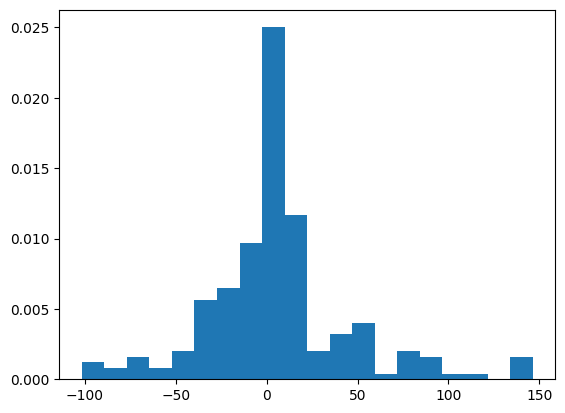

In [32]:
from tqdm.notebook import trange
import matplotlib.pyplot as plt

dets = []
for _ in trange(200):
    v, w = rand_ortho_pair(D+1)
    rho = states_to_density(v, w)
    g = rho_to_g(rho)
    g.simplify()
    det = M.subs(dict(zip(symbols(f'g:{len(g)}'), g))).det().simplify()
    dets.append(float(det))
print(min(map(abs, dets)))
plt.hist(dets, density=True, bins=20)
plt.show()